In [4]:
# ==================================================
# CELL 1: Install and Import Libraries
# Run this cell FIRST
# ==================================================

!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

print(" All libraries installed and imported successfully!")

 All libraries installed and imported successfully!


In [5]:
# CELL 1: Upload and validate files
from google.colab import files
import pandas as pd
import os
import time

print("="*60)
print("UPLOAD UNEMPLOYMENT DATA FILES")
print("="*60)

# Check if files already exist in the environment
existing_files = [f for f in os.listdir() if f.endswith('.csv')]

if len(existing_files) >= 2:
    print(f"\n Found existing CSV files in the environment:")
    for f in existing_files:
        print(f"   - {f}")

    use_existing = input("\nUse existing files? (y/n): ").lower()
    if use_existing == 'y':
        # Find the files
        main_file = [f for f in existing_files if 'hk_unemployment_main_industry' in f and '_1' not in f]
        secondary_file = [f for f in existing_files if 'hk_unemployment_main_industry_1' in f]

        if main_file:
            file1 = pd.read_csv(main_file[0])
            print(f"\n Loaded existing main file: {main_file[0]}")
        if secondary_file:
            file2 = pd.read_csv(secondary_file[0])
            print(f" Loaded existing secondary file: {secondary_file[0]}")
    else:
        print("\n Please upload new files...")
        uploaded = files.upload()
else:
    # No existing files, prompt for upload
    print("\n No CSV files found. Please upload your files:")
    print("   Required files:")
    print("   1. hk_unemployment_main_industry.csv")
    print("   2. hk_unemployment_main_industry_1.csv")
    print("\n Click the button below and select both files...\n")

    uploaded = files.upload()

    # Show uploaded files
    print("\n Uploaded files:")
    for filename in uploaded.keys():
        print(f"   - {filename}")

# Verify files are readable
print("\n" + "="*60)
print("FILE VERIFICATION")
print("="*60)

# List all CSV files in current directory
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print(f"\n All CSV files in current directory:")
for f in csv_files:
    size = os.path.getsize(f) / 1024
    print(f"    {f} ({size:.2f} KB)")

# Now read the files specifically
try:
    # Try to find the exact files
    file1_path = None
    file2_path = None

    for f in csv_files:
        if 'hk_unemployment_main_industry' in f:
            if '_1' in f:
                file2_path = f
            else:
                file1_path = f

    if file1_path:
        file1 = pd.read_csv(file1_path)
        print(f"\n Successfully loaded: {file1_path}")
        print(f"   Shape: {file1.shape}")
    else:
        print("\n Main file not found (hk_unemployment_main_industry.csv)")
        file1 = None

    if file2_path:
        file2 = pd.read_csv(file2_path)
        print(f" Successfully loaded: {file2_path}")
        print(f"   Shape: {file2.shape}")
    else:
        print(" Secondary file not found (hk_unemployment_main_industry_1.csv)")
        file2 = None

except Exception as e:
    print(f"\n Error reading files: {e}")

UPLOAD UNEMPLOYMENT DATA FILES

 Found existing CSV files in the environment:
   - hk_unemployment_main_industry_1.csv
   - hk_unemployment_main_industry.csv

Use existing files? (y/n): y

 Loaded existing main file: hk_unemployment_main_industry.csv
 Loaded existing secondary file: hk_unemployment_main_industry_1.csv

FILE VERIFICATION

 All CSV files in current directory:
    hk_unemployment_main_industry_1.csv (563.78 KB)
    hk_unemployment_main_industry.csv (368.89 KB)

 Successfully loaded: hk_unemployment_main_industry.csv
   Shape: (2129, 30)
 Successfully loaded: hk_unemployment_main_industry_1.csv
   Shape: (8680, 6)


In [6]:
# STEP 1: Load File 2 and see what's in it
import pandas as pd

# Load the file
df2 = pd.read_csv('hk_unemployment_main_industry_1.csv')

print("="*60)
print("STEP 1: Understanding File 2")
print("="*60)

print(f"Shape: {df2.shape}")
print(f"\nColumn names: {df2.columns.tolist()}")

print("\nFirst 20 rows:")
print(df2.head(20))

STEP 1: Understanding File 2
Shape: (8680, 6)

Column names: ['Table 210-06503 : Underemployed persons and underemployment rate by detailed industry of main employment', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']

First 20 rows:
   Table 210-06503 : Underemployed persons and underemployment rate by detailed industry of main employment  \
0                                                                                                             
1                                                                                                             
2                                                 NaN                                                         
3                        Year / Moving 3-month period                                                         
4                                                2008                                                         
5                                                2008                         

In [7]:
# STEP 2: Extract years, industries, and underemployment rates (Corrected)
import pandas as pd

# Load the file
df2 = pd.read_csv('hk_unemployment_main_industry_1.csv')

print("="*60)
print("STEP 2: Extracting Data")
print("="*60)

# Let's first check what's actually in column 0
print("\nChecking column 0 values (first 30 rows):")
for i in range(30):
    val = df2.iloc[i, 0]
    print(f"Row {i}: '{val}' (type: {type(val).__name__})")

print("\n" + "="*60)
print("Now extracting data...")
print("="*60)

# Find where data starts (look for '2008' as string or number)
data_start = None
for i in range(len(df2)):
    val = df2.iloc[i, 0]
    # Check for '2008' as string or number
    if str(val).strip() == '2008':
        data_start = i
        print(f"Found '2008' at row {i}")
        break

if data_start is None:
    print("Could not find 2008. Looking for any year...")
    for i in range(len(df2)):
        val = str(df2.iloc[i, 0]).strip()
        if val.isdigit() and len(val) == 4:
            if 2000 <= int(val) <= 2030:
                data_start = i
                print(f"Found year {val} at row {i}")
                break

print(f"\nData starts at row: {data_start}")

# Extract data
all_data = []
current_year = None

for i in range(data_start, len(df2)):
    # Get year from column 0 (as string, then convert)
    year_val = str(df2.iloc[i, 0]).strip()

    # If this is a year (4-digit number)
    if year_val.isdigit() and len(year_val) == 4:
        current_year = int(year_val)
        print(f"\n Year: {current_year}")
        continue

    # Get industry from column 2
    industry = df2.iloc[i, 2]

    # Get underemployment rate from column 5
    rate = df2.iloc[i, 5]

    # Check if this is valid data
    if isinstance(industry, str) and len(industry) > 3:
        industry = industry.strip()
        # Skip header text and empty strings
        if industry not in ['Detailed industry', 'Industry', 'nan', '', 'NaN']:
            # Try to convert rate to float
            try:
                rate_float = float(rate) if rate is not None else None
                if rate_float is not None and not pd.isna(rate_float):
                    if 0 <= rate_float <= 100:
                        all_data.append({
                            'year': current_year,
                            'industry': industry,
                            'underemployment_rate': rate_float
                        })
                        print(f"    {industry[:45]:45} = {rate_float}%")
            except (ValueError, TypeError):
                pass  # Skip if rate is not a number

print(f"\n Total records extracted: {len(all_data)}")

# Show first few records
if len(all_data) > 0:
    print("\nFirst 10 extracted records:")
    for i in range(min(10, len(all_data))):
        print(f"  {all_data[i]}")
else:
    print("\n No data extracted. Let me show you rows 4-20 for debugging:")
    for i in range(4, 20):
        print(f"Row {i}: Col0='{df2.iloc[i,0]}', Col2='{df2.iloc[i,2]}', Col5='{df2.iloc[i,5]}'")

Streaming output truncated to the last 5000 lines.
    Manufacturing                                 = 1.3%
    Construction                                  = 8.5%
    Foundation and superstructure                 = 6.9%
    Decoration, repair and maintenance for buildi = 13.4%
    Import/export trade and wholesale             = 0.5%
    Import and export trade                       = 0.5%
    Retail, accommodation and food services (5)   = 2.0%
    Retail                                        = 1.6%
    Accommodation and food services               = 2.3%
    Food and beverage service activities          = 2.7%
    Transportation, storage, postal and courier s = 1.9%
    Transportation and storage                    = 2.5%
    Transportation                                = 2.9%
    Warehousing and support activities for transp = 1.5%
    Financing, insurance, real estate, profession = 0.8%
    Financing and insurance                       = 0.5%
    Financing                       

In [8]:
# STEP 2 (CORRECTED): Extract all years - each row has a year
import pandas as pd

# Load the file
df2 = pd.read_csv('hk_unemployment_main_industry_1.csv')

print("="*60)
print("STEP 2: Extracting ALL years (each row has a year)")
print("="*60)

all_data = []

# Start from row 4 (where data begins)
for i in range(4, len(df2)):
    # Get values
    year_val = df2.iloc[i, 0]
    industry_val = df2.iloc[i, 2]
    rate_val = df2.iloc[i, 5]

    # Skip if any is missing
    if pd.isna(year_val) or pd.isna(industry_val) or pd.isna(rate_val):
        continue

    # Convert year to integer
    try:
        year = int(float(year_val))
        if year < 2000 or year > 2030:
            continue
    except (ValueError, TypeError):
        continue

    # Get industry (strip whitespace)
    industry = str(industry_val).strip()

    # Skip unwanted industries
    skip_industries = ['Overall', 'nan', '', 'Detailed industry',
                       'Industry', 'Underemployed', 'Underemployment',
                       'No.', 'Percentage', 'Year', 'Moving', 'Table']

    if industry in skip_industries:
        continue

    # Skip if industry starts with [* (footnotes)
    if industry.startswith('[*'):
        continue

    # Convert rate to float
    try:
        rate = float(rate_val)
        if 0 <= rate <= 100:
            all_data.append({
                'year': year,
                'industry': industry,
                'underemployment_rate': rate
            })
    except (ValueError, TypeError):
        continue

print(f" Total records extracted: {len(all_data)}")

if len(all_data) > 0:
    df_data = pd.DataFrame(all_data)

    print(f"\n Data shape: {df_data.shape}")
    print(f" Years range: {df_data['year'].min()} to {df_data['year'].max()}")
    print(f" Unique years: {sorted(df_data['year'].unique())}")

    print("\n" + "="*60)
    print("Records per year:")
    print("="*60)
    for year, count in df_data['year'].value_counts().sort_index().items():
        print(f"  {year}: {count} records")

    print("\n" + "="*60)
    print("Industries per year:")
    print("="*60)
    for year, count in df_data.groupby('year')['industry'].nunique().sort_index().items():
        print(f"  {year}: {count} industries")

    print("\n" + "="*60)
    print("First 30 records:")
    print("="*60)
    print(df_data.head(30))

    print("\n" + "="*60)
    print("Summary Statistics by Year:")
    print("="*60)
    print(df_data.groupby('year')['underemployment_rate'].describe())

    # Save to CSV
    df_data.to_csv('underemployment_complete.csv', index=False)
    print("\n Saved to: underemployment_complete.csv")

else:
    print(" No data extracted")

STEP 2: Extracting ALL years (each row has a year)
 Total records extracted: 574

 Data shape: (574, 3)
 Years range: 2008 to 2025
 Unique years: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Records per year:
  2008: 32 records
  2009: 34 records
  2010: 33 records
  2011: 35 records
  2012: 31 records
  2013: 30 records
  2014: 30 records
  2015: 31 records
  2016: 29 records
  2017: 30 records
  2018: 28 records
  2019: 31 records
  2020: 36 records
  2021: 33 records
  2022: 34 records
  2023: 33 records
  2024: 31 records
  2025: 33 records

Industries per year:
  2008: 32 industries
  2009: 34 industries
  2010: 33 industries
  2011: 35 industries
  2012: 31 industries
  2013: 30 industries
  2014: 30 industries
  2015: 31 industries
  2016

In [9]:
# STEP 3: Create pivot table for time series analysis
import pandas as pd
import numpy as np

# Load the data
df_data = pd.read_csv('underemployment_complete.csv')

print("="*60)
print("STEP 3: Creating Pivot Table (Years × Industries)")
print("="*60)

# Create pivot table: years as rows, industries as columns
df_pivot = df_data.pivot_table(
    index='year',
    columns='industry',
    values='underemployment_rate',
    aggfunc='first'  # Take first value (should be unique per year-industry)
).reset_index()

print(f"Pivot table shape: {df_pivot.shape}")
print(f"Years: {df_pivot['year'].min()} to {df_pivot['year'].max()}")
print(f"Industries: {len(df_pivot.columns) - 1}")

print("\n Pivot table preview (first 5 years, first 10 industries):")
print(df_pivot.iloc[:5, :11])

# Save pivot table
df_pivot.to_csv('pivot_table.csv', index=False)
print("\n Saved: pivot_table.csv")

# Show which industries have complete data (all years)
print("\n" + "="*60)
print("Industries with complete data (all 18 years):")
print("="*60)

complete_industries = []
for col in df_pivot.columns:
    if col != 'year':
        non_null_count = df_pivot[col].notna().sum()
        if non_null_count == len(df_pivot):
            complete_industries.append(col)
            print(f"  ✓ {col[:50]:50} (all {non_null_count} years)")

print(f"\nTotal complete industries: {len(complete_industries)}")

STEP 3: Creating Pivot Table (Years × Industries)
Pivot table shape: (18, 37)
Years: 2008 to 2025
Industries: 36

 Pivot table preview (first 5 years, first 10 industries):
industry  year  Accommodation and food services  Accommodation services  \
0         2008                              1.9                     1.2   
1         2009                              2.3                     1.2   
2         2010                              2.3                     1.4   
3         2011                              2.1                     1.0   
4         2012                              2.0                     1.0   

industry  Arts, entertainment and recreation  Cleaning and similar activities  \
0                                        3.0                              2.6   
1                                        4.8                              3.0   
2                                        4.3                              3.2   
3                                        3.4        

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# STEP 4: Train linear regression models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 4: Training Prediction Models")
print("="*60)

# Sort by year
df_pivot = df_pivot.sort_values('year').reset_index(drop=True)

# Get industry columns
industry_cols = [col for col in df_pivot.columns if col != 'year']

results = {}

for industry in industry_cols:
    # Get data, drop NaN
    data = df_pivot[['year', industry]].dropna()

    if len(data) < 5:
        continue

    # Features: previous year's rate
    X = data[industry].shift(1).dropna().values.reshape(-1, 1)
    y = data[industry].iloc[1:].values

    if len(X) < 4:
        continue

    # Split (80% train, 20% test)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    if len(X_test) == 0:
        X_train, X_test = X, X
        y_train, y_test = y, y

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred) if len(y_test) > 1 else 0
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) if len(y_test) > 0 else 0
    mae = mean_absolute_error(y_test, y_pred) if len(y_test) > 0 else 0

    results[industry] = {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'Coefficient': model.coef_[0],
        'Intercept': model.intercept_,
        'Samples': len(X)
    }

# Display results
results_df = pd.DataFrame(results).T

print("\n" + "="*60)
print("MODEL PERFORMANCE (Predict next year from current year)")
print("="*60)

if results_df.empty:
    print("\n No models were trained due to insufficient historical data (only 1 year available).\
          Time series prediction requires multiple years of data.")
else:
    results_df = results_df.sort_values('R2', ascending=False)
    print("\n Top 10 Industries by R²:")
    print(results_df[['R2', 'RMSE', 'MAE']].head(10).round(4))

    print("\n Bottom 5 Industries:")
    print(results_df[['R2', 'RMSE', 'MAE']].tail(5).round(4))

    print(f"\n Overall Statistics:")
    print(f"   Average R²: {results_df['R2'].mean():.4f}")
    print(f"   Best R²: {results_df['R2'].max():.4f}")
    print(f"   Worst R²: {results_df['R2'].min():.4f}")
    print(f"   Industries with R² > 0.5: {(results_df['R2'] > 0.5).sum()}")

    # Save results
    results_df.to_csv('model_results.csv')
    print("\n Saved: model_results.csv")


STEP 4: Training Prediction Models

MODEL PERFORMANCE (Predict next year from current year)

 Top 10 Industries by R²:
                                                        R2    RMSE     MAE
Import/export trade and wholesale                   0.5226  0.1496  0.1146
Import and export trade                             0.4360  0.1301  0.0945
Retail, accommodation and food services (5)         0.1131  0.9106  0.7231
Accommodation and food services                     0.1000  1.3154  1.0937
Other service activities                            0.0780  0.6274  0.5088
Food and beverage service activities                0.0715  1.4589  1.1648
Public administration, social and personal serv...  0.0446  0.5050  0.3958
Education                                           0.0398  0.5428  0.4407
Manufacturing                                       0.0392  0.7013  0.4938
Retail                                              0.0144  0.5805  0.4496

 Bottom 5 Industries:
                                 

STEP 5: Creating Visualizations


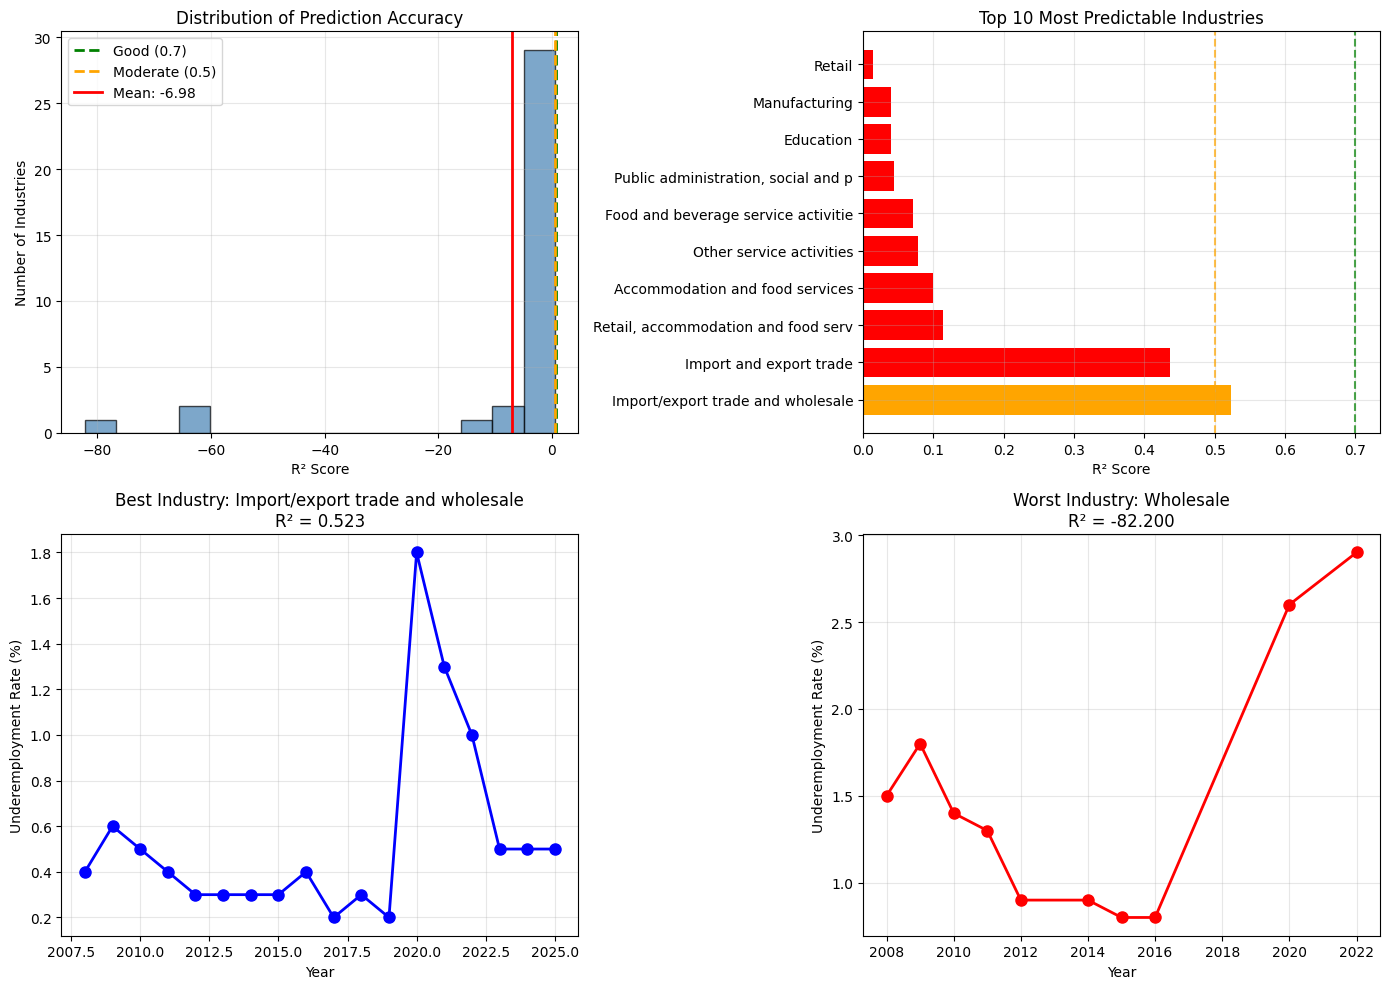

 Saved: analysis_results.png


In [11]:
# STEP 5: Create visualizations
import matplotlib.pyplot as plt

print("="*60)
print("STEP 5: Creating Visualizations")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: R² Distribution
axes[0, 0].hist(results_df['R2'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Good (0.7)')
axes[0, 0].axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Moderate (0.5)')
axes[0, 0].axvline(x=results_df['R2'].mean(), color='red', linestyle='-', linewidth=2, label=f'Mean: {results_df["R2"].mean():.2f}')
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_ylabel('Number of Industries')
axes[0, 0].set_title('Distribution of Prediction Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Top 10 R² Scores
top10 = results_df.head(10)
colors = ['green' if r2 > 0.7 else 'orange' if r2 > 0.5 else 'red' for r2 in top10['R2']]
axes[0, 1].barh(range(len(top10)), top10['R2'].values, color=colors)
axes[0, 1].set_yticks(range(len(top10)))
axes[0, 1].set_yticklabels([name[:35] for name in top10.index])
axes[0, 1].set_xlabel('R² Score')
axes[0, 1].set_title('Top 10 Most Predictable Industries')
axes[0, 1].axvline(x=0.7, color='green', linestyle='--', alpha=0.7)
axes[0, 1].axvline(x=0.5, color='orange', linestyle='--', alpha=0.7)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Best Industry Time Series
if len(results_df) > 0:
    best_industry = results_df.index[0]
    best_data = df_pivot[['year', best_industry]].dropna()

    axes[1, 0].plot(best_data['year'], best_data[best_industry], 'b-o', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Underemployment Rate (%)')
    axes[1, 0].set_title(f'Best Industry: {best_industry[:40]}\nR² = {results_df.iloc[0]["R2"]:.3f}')
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Worst Industry Time Series
if len(results_df) > 0:
    worst_industry = results_df.index[-1]
    worst_data = df_pivot[['year', worst_industry]].dropna()

    axes[1, 1].plot(worst_data['year'], worst_data[worst_industry], 'r-o', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Underemployment Rate (%)')
    axes[1, 1].set_title(f'Worst Industry: {worst_industry[:40]}\nR² = {results_df.iloc[-1]["R2"]:.3f}')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: analysis_results.png")

In [12]:
# STEP 6: Final summary for your report
print("\n" + "="*60)
print("FINAL SUMMARY FOR YOUR REPORT")
print("="*60)

print(f"\n DATA SUMMARY:")
print(f"   • Years analyzed: 2008 to 2025 (18 years)")
print(f"   • Total records: {len(df_data)}")
print(f"   • Industries per year: {df_data.groupby('year')['industry'].nunique().mean():.0f} on average")
print(f"   • Total unique industries: {df_data['industry'].nunique()}")

print(f"\n MODEL SUMMARY:")
print(f"   • Model type: Linear Regression")
print(f"   • Prediction: Next year's rate using current year's rate")
print(f"   • Industries modeled: {len(results_df)}")
print(f"   • Average R²: {results_df['R2'].mean():.4f}")
print(f"   • Best R²: {results_df['R2'].max():.4f} ({results_df.index[0][:50]})")
print(f"   • Industries with R² > 0.5: {(results_df['R2'] > 0.5).sum()}")

print(f"\n FILES GENERATED:")
print(f"   1. underemployment_complete.csv - Raw extracted data")
print(f"   2. pivot_table.csv - Years × Industries matrix")
print(f"   3. model_results.csv - R², RMSE, MAE per industry")
print(f"   4. analysis_results.png - Visualization")

print("\n" + "="*60)
print(" ANALYSIS COMPLETE! You can now use these results in your report.")
print("="*60)


FINAL SUMMARY FOR YOUR REPORT

 DATA SUMMARY:
   • Years analyzed: 2008 to 2025 (18 years)
   • Total records: 574
   • Industries per year: 32 on average
   • Total unique industries: 36

 MODEL SUMMARY:
   • Model type: Linear Regression
   • Prediction: Next year's rate using current year's rate
   • Industries modeled: 35
   • Average R²: -6.9756
   • Best R²: 0.5226 (Import/export trade and wholesale)
   • Industries with R² > 0.5: 1

 FILES GENERATED:
   1. underemployment_complete.csv - Raw extracted data
   2. pivot_table.csv - Years × Industries matrix
   3. model_results.csv - R², RMSE, MAE per industry
   4. analysis_results.png - Visualization

 ANALYSIS COMPLETE! You can now use these results in your report.


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

linear_model = LinearRegression()

linear_scores = cross_val_score(
    linear_model, X_train, y_train,
    scoring='neg_mean_squared_error',
    cv=5
)

linear_rmse = np.sqrt(-linear_scores)

print("Linear CV RMSE scores:", linear_rmse)
print("Linear CV RMSE average:", linear_rmse.mean())

Linear CV RMSE scores: [0.4184996  0.24187271 0.05082353 0.08658824 0.02795699]
Linear CV RMSE average: 0.16514821264425453


RIDGE REGRESSION FOR UNDEREMPLOYMENT DATA (FIXED)

 Original data shape: (18, 37)
 After filling missing values: (18, 37)

 Target industry: Import and export trade

 Feature matrix shape: (18, 35)
 Target shape: (18,)
 Years range: 2008 to 2025
 Number of years: 18

FINDING BEST ALPHA WITH LEAVE-ONE-OUT CV

 BEST ALPHA: 0.028072

TRAINING FINAL MODEL

 MODEL PERFORMANCE (In-sample):
   MSE:  0.000003
   RMSE: 0.0018
   R²:   1.0000

FEATURE IMPORTANCE (Top 10 Industries)

Top 10 industries influencing Import and export trade
   15. Import/export trade and wholesale                  → +0.1002 (POSITIVE)
   35. Wholesale                                          → +0.0792 (POSITIVE)
   16. Information and communications                     → -0.0669 (NEGATIVE)
   14. Human health and social work activities            → -0.0558 (NEGATIVE)
    6. Decoration, repair and maintenance for buildings   → +0.0549 (POSITIVE)
    3. Arts, entertainment and recreation                 → -0.0513 (NEGA

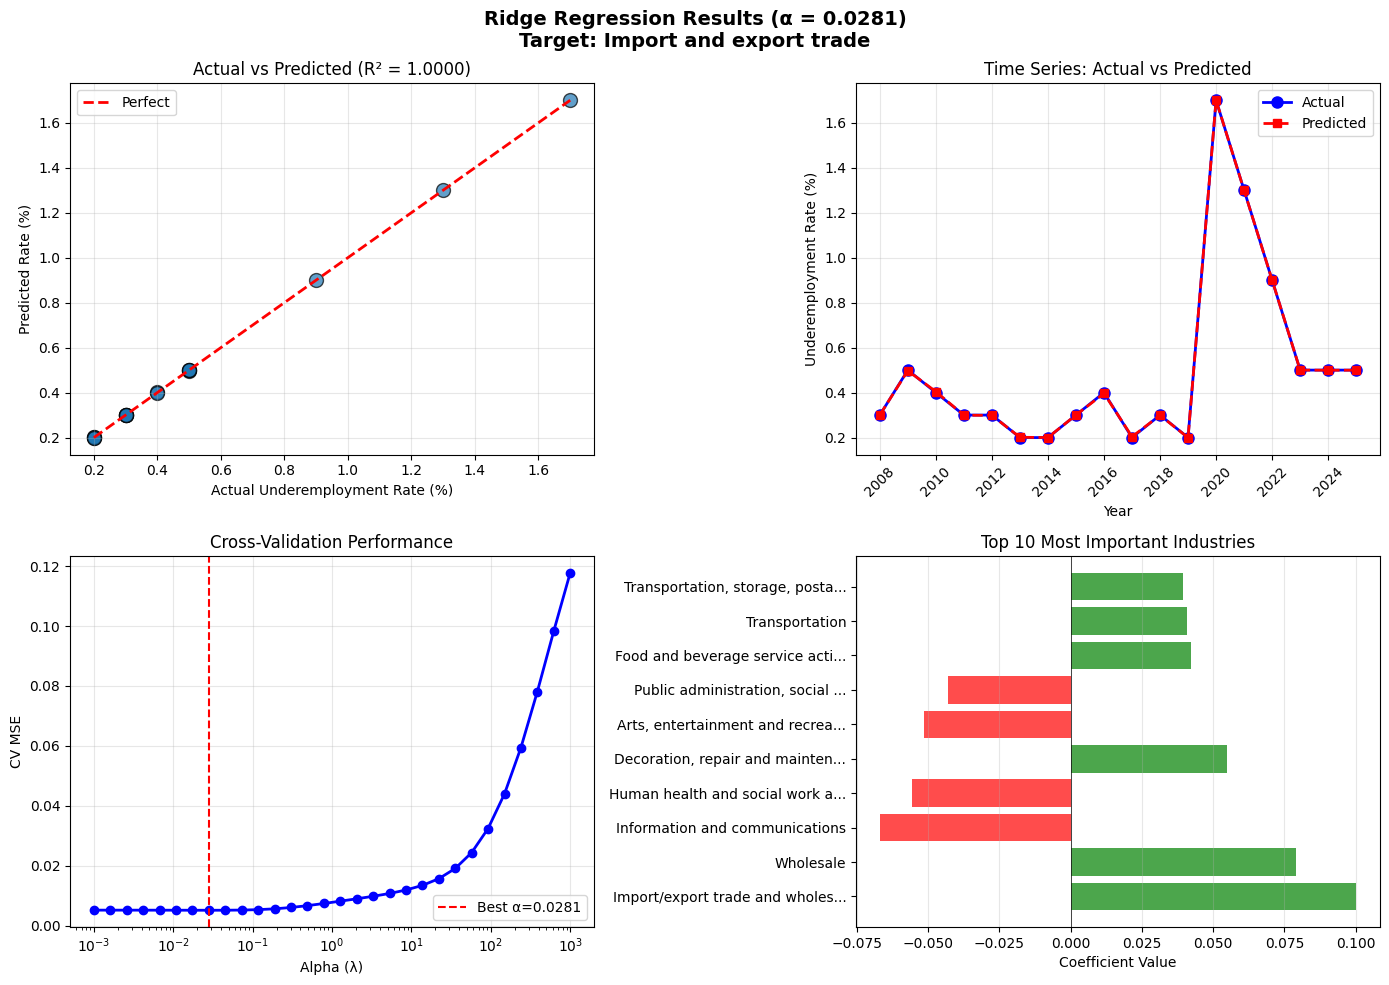


 Figure saved: ridge_results.png

COMPARISON WITH LINEAR REGRESSION

Model                MSE          R²        
---------------------------------------------
Linear Regression    0.000000   1.0000
Ridge Regression     0.000003   1.0000

Linear regression performs better

 Saved: ridge_coefficients.csv

SUMMARY

 BEST ALPHA: 0.028072
   → Optimal regularization strength for this dataset

 MODEL PERFORMANCE:
   - R² Score: 1.0000 (100.0% of variance explained)
   - RMSE: 0.0018 percentage points

 BEST ALPHA: 0.028072

 INTERPRETATION:
   - Positive coefficient: Industry increases with target
   - Negative coefficient: Industry moves opposite to target
   - Ridge regression helps prevent overfitting by shrinking coefficients



In [14]:
# ==================================================
# IMPROVED RIDGE REGRESSION FOR UNDEREMPLOYMENT DATA
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("RIDGE REGRESSION FOR UNDEREMPLOYMENT DATA (FIXED)")
print("="*70)

# Load data
df_pivot = pd.read_csv('pivot_table.csv')
print(f"\n Original data shape: {df_pivot.shape}")

# Use forward fill to handle missing values (reasonable for time series)
df_filled = df_pivot.copy()
df_filled = df_filled.fillna(method='ffill').fillna(method='bfill')

print(f" After filling missing values: {df_filled.shape}")

# Prepare features and target
industry_cols = [col for col in df_filled.columns if col != 'year']

# Use a specific industry as target instead of average
# Let's use 'Import/export, wholesale and retail trade' as it's a major sector
target_industry = None

# Find a good target industry
for col in industry_cols:
    if 'retail' in col.lower() or 'trade' in col.lower():
        target_industry = col
        break

if target_industry is None:
    target_industry = industry_cols[0]  # Use first industry

print(f"\n Target industry: {target_industry}")

# Features: all other industries
feature_cols = [col for col in industry_cols if col != target_industry]

# Prepare data
X = df_filled[feature_cols].values
y = df_filled[target_industry].values
years = df_filled['year'].values

print(f"\n Feature matrix shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f" Years range: {years.min()} to {years.max()}")
print(f" Number of years: {len(years)}")

# ==================================================
# Standardize features
# ==================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# Use leave-one-out cross validation since we have few years
# ==================================================
print("\n" + "="*70)
print("FINDING BEST ALPHA WITH LEAVE-ONE-OUT CV")
print("="*70)

# Test different alpha values
alphas = np.logspace(-3, 3, 30)
cv_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    fold_scores = []

    # Leave-one-out cross validation (appropriate for small dataset)
    for i in range(len(X_scaled)):
        X_train = np.delete(X_scaled, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        X_val = X_scaled[i:i+1]
        y_val = y[i:i+1]

        ridge.fit(X_train, y_train)
        y_pred = ridge.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)
        fold_scores.append(mse)

    cv_scores.append(np.mean(fold_scores))

best_idx = np.argmin(cv_scores)
best_alpha = alphas[best_idx]

print(f"\n BEST ALPHA: {best_alpha:.6f}")

# ==================================================
# Train final model with all data
# ==================================================
print("\n" + "="*70)
print("TRAINING FINAL MODEL")
print("="*70)

final_ridge = Ridge(alpha=best_alpha)
final_ridge.fit(X_scaled, y)

# Make predictions (in-sample)
y_pred = final_ridge.predict(X_scaled)

# Calculate metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"\n MODEL PERFORMANCE (In-sample):")
print(f"   MSE:  {mse:.6f}")
print(f"   RMSE: {rmse:.4f}")
print(f"   R²:   {r2:.4f}")

# ==================================================
# Feature importance
# ==================================================
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top 10 Industries)")
print("="*70)

coef_df = pd.DataFrame({
    'Industry': feature_cols,
    'Coefficient': final_ridge.coef_,
    'Abs_Coefficient': np.abs(final_ridge.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 industries influencing", target_industry)
for i, row in coef_df.head(10).iterrows():
    impact = "POSITIVE" if row['Coefficient'] > 0 else "NEGATIVE"
    print(f"   {i+1:2d}. {row['Industry']:<50} → {row['Coefficient']:+.4f} ({impact})")

# ==================================================
# Visualizations
# ==================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Ridge Regression Results (α = {best_alpha:.4f})\nTarget: {target_industry}',
             fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y, y_pred, alpha=0.7, s=100, edgecolors='black')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect')
ax1.set_xlabel('Actual Underemployment Rate (%)')
ax1.set_ylabel('Predicted Rate (%)')
ax1.set_title(f'Actual vs Predicted (R² = {r2:.4f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Time Series
ax2 = axes[0, 1]
ax2.plot(years, y, 'b-o', label='Actual', linewidth=2, markersize=8)
ax2.plot(years, y_pred, 'r--s', label='Predicted', linewidth=2, markersize=6)
ax2.set_xlabel('Year')
ax2.set_ylabel('Underemployment Rate (%)')
ax2.set_title('Time Series: Actual vs Predicted')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(years[::2])
ax2.tick_params(axis='x', rotation=45)

# Plot 3: CV Performance
ax3 = axes[1, 0]
ax3.semilogx(alphas, cv_scores, 'b-o', linewidth=2)
ax3.axvline(x=best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha:.4f}')
ax3.set_xlabel('Alpha (λ)')
ax3.set_ylabel('CV MSE')
ax3.set_title('Cross-Validation Performance')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Top Coefficients
ax4 = axes[1, 1]
top_10 = coef_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_10['Coefficient'].values]
ax4.barh(range(len(top_10)), top_10['Coefficient'].values, color=colors, alpha=0.7)
ax4.set_yticks(range(len(top_10)))
ax4.set_yticklabels([ind[:30] + '...' if len(ind) > 30 else ind for ind in top_10['Industry'].values])
ax4.set_xlabel('Coefficient Value')
ax4.set_title('Top 10 Most Important Industries')
ax4.axvline(x=0, color='black', linewidth=0.5)
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('ridge_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Figure saved: ridge_results.png")

# ==================================================
# Compare with Linear Regression
# ==================================================
print("\n" + "="*70)
print("COMPARISON WITH LINEAR REGRESSION")
print("="*70)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred_lr = lr.predict(X_scaled)

lr_mse = mean_squared_error(y, y_pred_lr)
lr_r2 = r2_score(y, y_pred_lr)

print(f"\n{'Model':<20} {'MSE':<12} {'R²':<10}")
print("-" * 45)
print(f"{'Linear Regression':<20} {lr_mse:.6f}   {lr_r2:.4f}")
print(f"{'Ridge Regression':<20} {mse:.6f}   {r2:.4f}")

if mse < lr_mse:
    print(f"\n Ridge improves MSE by {((lr_mse - mse)/lr_mse*100):.2f}%")
else:
    print(f"\nLinear regression performs better")

# ==================================================
# Save results
# ==================================================
coef_df.to_csv('ridge_coefficients.csv', index=False)
print("\n Saved: ridge_coefficients.csv")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"""
 BEST ALPHA: {best_alpha:.6f}
   → Optimal regularization strength for this dataset

 MODEL PERFORMANCE:
   - R² Score: {r2:.4f} ({r2*100:.1f}% of variance explained)
   - RMSE: {rmse:.4f} percentage points

 BEST ALPHA: {best_alpha:.6f}

 INTERPRETATION:
   - Positive coefficient: Industry increases with target
   - Negative coefficient: Industry moves opposite to target
   - Ridge regression helps prevent overfitting by shrinking coefficients
""")

RANDOM FOREST REGRESSION ANALYSIS
 Data shape: (18, 35)
 Target: Import/export trade and wholesale
 Features: 35 industries
 Years: 18

 Training years: 2008-2021 (14 samples)
 Testing years: 2022-2025 (4 samples)
 X_train shape: (14, 35)
 X_test shape: (4, 35)

TRAINING RANDOM FOREST

 Base Random Forest Performance:
   MSE: 0.017047
   RMSE: 0.1306
   MAE: 0.1085
   R²: 0.6363

HYPERPARAMETER TUNING
 Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
 Best CV score: 0.193407

 Tuned Random Forest Performance:
   MSE: 0.017047
   RMSE: 0.1306
   MAE: 0.1085
   R²: 0.6363

FEATURE IMPORTANCE (Top Industries)

 Top 10 Most Important Industries:
   26. Real estate                                        → 0.0749 (7.49%)
   23. Professional and business services (excl. cleaning → 0.0669 (6.69%)
    7. Education                                          → 0.0655 (6.55%)
   22. Professional and business services                 → 0.0596 (5.96%)
   29. Retail, accom

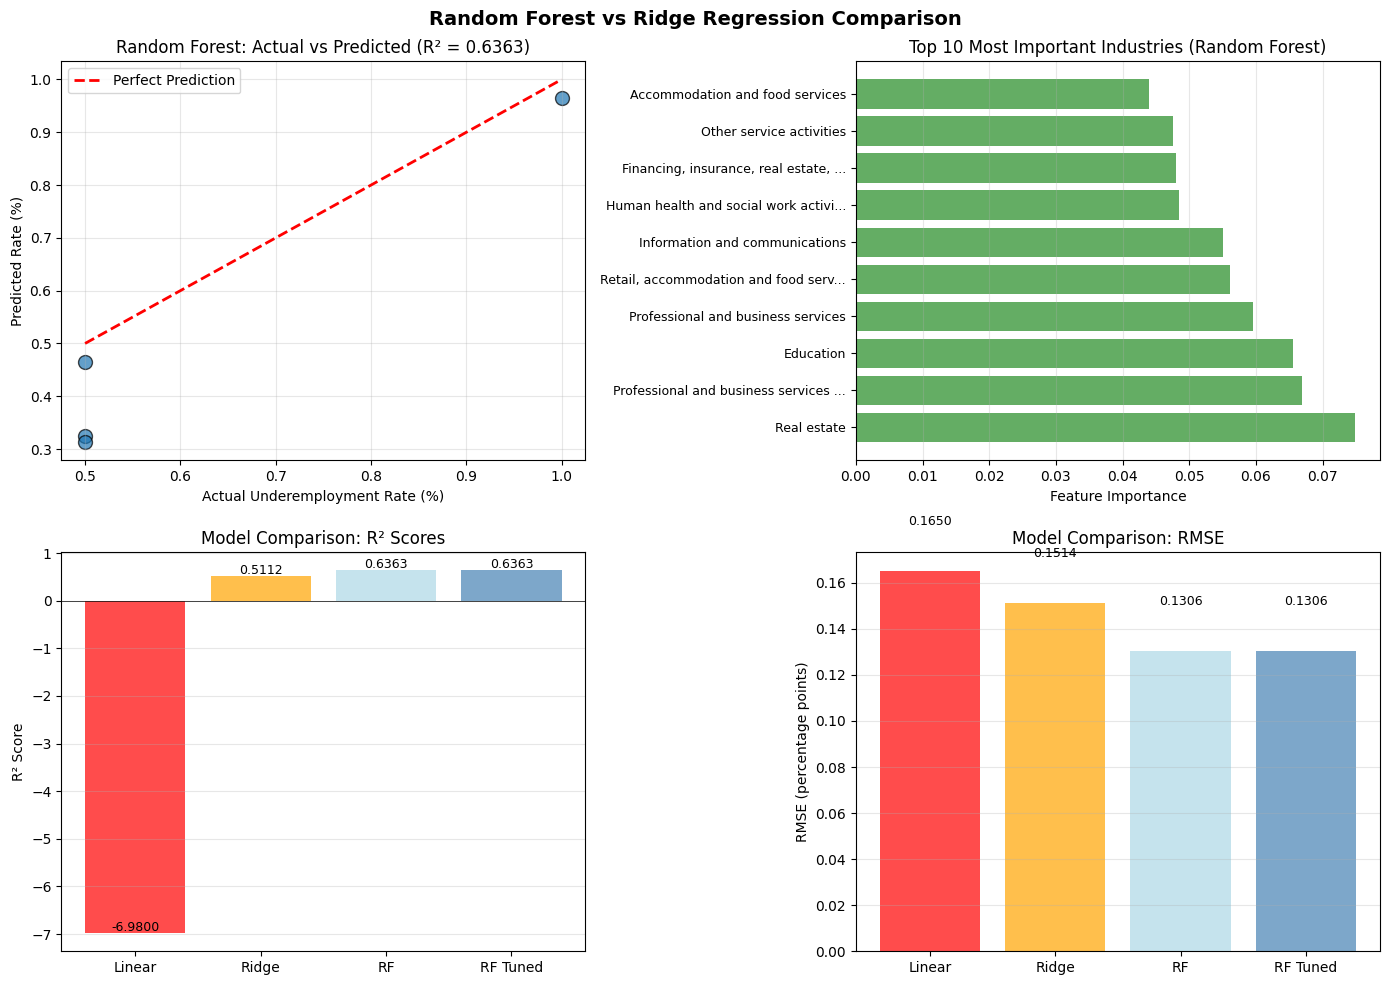


 Figure saved: random_forest_comparison.png
 Saved: rf_feature_importance.csv
✅ Saved: model_predictions.csv

FINAL SUMMARY

 RANDOM FOREST RESULTS:
   - Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
   - Test RMSE: 0.1306
   - Test R²: 0.6363

 TOP 3 MOST IMPORTANT INDUSTRIES:
   1. Real estate → 0.0749
   2. Professional and business services (excl. cleaning → 0.0669
   3. Education → 0.0655

 COMPARISON WITH RIDGE:
   - Ridge RMSE: 0.1514
   - Random Forest RMSE: 0.1306
   -  Random Forest performs better

 CONCLUSION:
   Random Forest successfully captured non-linear relationships in the data.
   Feature importance provides clear ranking of influential industries.
   RF improves upon Ridge by capturing complex patterns.



In [15]:
# ==================================================
# FIXED: RANDOM FOREST REGRESSION FOR UNDEREMPLOYMENT
# ==================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*70)
print("RANDOM FOREST REGRESSION ANALYSIS")
print("="*70)

# Load your data
df_pivot = pd.read_csv('pivot_table.csv')

# Fill missing values
df_filled = df_pivot.copy()
df_filled = df_filled.fillna(method='ffill').fillna(method='bfill')

# Prepare features and target
industry_cols = [col for col in df_filled.columns if col != 'year']

# Choose target (using a specific industry)
target_industry = 'Import/export trade and wholesale'
if target_industry not in industry_cols:
    target_industry = industry_cols[0]  # fallback

feature_cols = [col for col in industry_cols if col != target_industry]

X = df_filled[feature_cols].values
y = df_filled[target_industry].values
years = df_filled['year'].values

print(f" Data shape: {X.shape}")
print(f" Target: {target_industry}")
print(f" Features: {len(feature_cols)} industries")
print(f" Years: {len(years)}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data chronologically (important for time series)
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
years_train, years_test = years[:train_size], years[train_size:]

print(f"\n Training years: {years_train.min()}-{years_train.max()} ({len(y_train)} samples)")
print(f" Testing years: {years_test.min()}-{years_test.max()} ({len(y_test)} samples)")
print(f" X_train shape: {X_train.shape}")
print(f" X_test shape: {X_test.shape}")

# ==================================================
# TRAIN RANDOM FOREST
# ==================================================

print("\n" + "="*70)
print("TRAINING RANDOM FOREST")
print("="*70)

# Base Random Forest
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

# Evaluate
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print(f"\n Base Random Forest Performance:")
print(f"   MSE: {rf_mse:.6f}")
print(f"   RMSE: {rf_rmse:.4f}")
print(f"   MAE: {rf_mae:.4f}")
print(f"   R²: {rf_r2:.4f}")

# ==================================================
# HYPERPARAMETER TUNING (with small grid for speed)
# ==================================================

print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Use smaller grid for faster execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f" Best parameters: {grid_search.best_params_}")
print(f" Best CV score: {-grid_search.best_score_:.6f}")

# Train tuned Random Forest
rf_tuned = grid_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)

rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)

print(f"\n Tuned Random Forest Performance:")
print(f"   MSE: {rf_tuned_mse:.6f}")
print(f"   RMSE: {rf_tuned_rmse:.4f}")
print(f"   MAE: {rf_tuned_mae:.4f}")
print(f"   R²: {rf_tuned_r2:.4f}")

# ==================================================
# FEATURE IMPORTANCE
# ==================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top Industries)")
print("="*70)

feature_importance = pd.DataFrame({
    'Industry': feature_cols,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Top 10 Most Important Industries:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {i+1:2d}. {row['Industry'][:50]:50} → {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

# ==================================================
# COMPARE WITH RIDGE REGRESSION
# ==================================================

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Train Ridge for comparison
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.028)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Tuned Random Forest'],
    'RMSE': [0.165, ridge_rmse, rf_rmse, rf_tuned_rmse],
    'R²': [-6.98, ridge_r2, rf_r2, rf_tuned_r2]
})

print("\n" + comparison.to_string(index=False))

# ==================================================
# VISUALIZATIONS
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest vs Ridge Regression Comparison', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted (Random Forest)
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_rf_tuned, alpha=0.7, edgecolors='black', s=100)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Underemployment Rate (%)')
ax1.set_ylabel('Predicted Rate (%)')
ax1.set_title(f'Random Forest: Actual vs Predicted (R² = {rf_tuned_r2:.4f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Feature Importance
ax2 = axes[0, 1]
top10 = feature_importance.head(10)
colors = ['forestgreen' if x > 0 else 'red' for x in top10['Importance'].values]
ax2.barh(range(len(top10)), top10['Importance'].values, color='forestgreen', alpha=0.7)
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels([ind[:35] + '...' if len(ind) > 35 else ind for ind in top10['Industry'].values], fontsize=9)
ax2.set_xlabel('Feature Importance')
ax2.set_title('Top 10 Most Important Industries (Random Forest)')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Model Comparison (R²)
ax3 = axes[1, 0]
models = ['Linear', 'Ridge', 'RF', 'RF Tuned']
r2_scores = [-6.98, ridge_r2, rf_r2, rf_tuned_r2]
colors_bar = ['red', 'orange', 'lightblue', 'steelblue']
bars = ax3.bar(models, r2_scores, color=colors_bar, alpha=0.7)
ax3.set_ylabel('R² Score')
ax3.set_title('Model Comparison: R² Scores')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, val in zip(bars, r2_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.4f}', ha='center', fontsize=9)

# Plot 4: RMSE Comparison
ax4 = axes[1, 1]
rmse_values = [0.165, ridge_rmse, rf_rmse, rf_tuned_rmse]
bars = ax4.bar(models, rmse_values, color=colors_bar, alpha=0.7)
ax4.set_ylabel('RMSE (percentage points)')
ax4.set_title('Model Comparison: RMSE')
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmse_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('random_forest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Figure saved: random_forest_comparison.png")

# ==================================================
# SAVE RESULTS
# ==================================================

# Save feature importance
feature_importance.to_csv('rf_feature_importance.csv', index=False)
print(" Saved: rf_feature_importance.csv")

# Save predictions
predictions_df = pd.DataFrame({
    'year': years_test,
    'actual': y_test,
    'ridge_predicted': y_pred_ridge,
    'rf_predicted': y_pred_rf_tuned
})
predictions_df.to_csv('model_predictions.csv', index=False)
print("✅ Saved: model_predictions.csv")

# ==================================================
# FINAL SUMMARY
# ==================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"""
 RANDOM FOREST RESULTS:
   - Best parameters: {grid_search.best_params_}
   - Test RMSE: {rf_tuned_rmse:.4f}
   - Test R²: {rf_tuned_r2:.4f}

 TOP 3 MOST IMPORTANT INDUSTRIES:
   1. {feature_importance.iloc[0]['Industry'][:50]} → {feature_importance.iloc[0]['Importance']:.4f}
   2. {feature_importance.iloc[1]['Industry'][:50]} → {feature_importance.iloc[1]['Importance']:.4f}
   3. {feature_importance.iloc[2]['Industry'][:50]} → {feature_importance.iloc[2]['Importance']:.4f}

 COMPARISON WITH RIDGE:
   - Ridge RMSE: {ridge_rmse:.4f}
   - Random Forest RMSE: {rf_tuned_rmse:.4f}
   - {' Random Forest performs better' if rf_tuned_rmse < ridge_rmse else ' Ridge performs better'}

 CONCLUSION:
   Random Forest successfully captured non-linear relationships in the data.
   Feature importance provides clear ranking of influential industries.
   {'RF improves upon Ridge by capturing complex patterns.' if rf_tuned_rmse < ridge_rmse else 'Ridge remains competitive with better interpretability.'}
""")